<a href="https://colab.research.google.com/github/YuvanR/MotorcyclePriceModel/blob/main/MotorcyclePricesModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.base import clone
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, silhouette_score

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


In [15]:
from google.colab import files

uploaded = files.upload()

Saving BIKE DETAILS.csv.xls to BIKE DETAILS.csv (3).xls


In [16]:
df = pd.read_csv("BIKE DETAILS.csv.xls")

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (1061, 7)


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN


In [17]:
print("columns:")
print(df.columns)

print("general dataset information:")
df.info()

print("Missing values: " )
print(df.isnull().sum())

print("Summary statistics: ")
display(df.describe())


columns:
Index(['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven',
       'ex_showroom_price'],
      dtype='object')
general dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1061 entries, 0 to 1060
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   name               1061 non-null   object 
 1   selling_price      1061 non-null   int64  
 2   year               1061 non-null   int64  
 3   seller_type        1061 non-null   object 
 4   owner              1061 non-null   object 
 5   km_driven          1061 non-null   int64  
 6   ex_showroom_price  626 non-null    float64
dtypes: float64(1), int64(3), object(3)
memory usage: 58.2+ KB
Missing values: 
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven              0
ex_showroom_price    435
dtype: int64
Summary statistics: 


,selling_price,year,km_driven,ex_showroom_price
count,1061.000000,1061.000000,1061.000000,6.260000e+02
mean,59638.151744,2013.867107,34359.833176,8.795871e+04
std,56304.291973,4.301191,51623.152702,7.749659e+04
min,5000.000000,1988.000000,350.000000,3.049000e+04
25%,28000.000000,2011.000000,13500.000000,5.485200e+04
50%,45000.000000,2015.000000,25000.000000,7.275250e+04
75%,70000.000000,2017.000000,43000.000000,8.703150e+04
max,760000.000000,2020.000000,880000.000000,1.278000e+06


In [18]:
print("seller type counts:")
print(df["seller_type"].value_counts())

print("owner counts:")
print(df["owner"].value_counts())

print("number of unique motorcycle names:", df["name"].nunique())

print("top 20 motorcycle names:")
print(df["name"].value_counts().head(20))


seller type counts:
seller_type
Individual    1055
Dealer           6
Name: count, dtype: int64
owner counts:
owner
1st owner    924
2nd owner    123
3rd owner     11
4th owner      3
Name: count, dtype: int64
number of unique motorcycle names: 279
top 20 motorcycle names:
name
Bajaj Pulsar 150                 41
Royal Enfield Classic 350        27
Honda Activa [2000-2015]         23
Honda CB Hornet 160R             22
Bajaj Pulsar 180                 20
Royal Enfield Thunderbird 350    19
Hero Honda Splendor Plus         17
Yamaha FZ S V 2.0                16
Bajaj Discover 125               16
Honda Shine                      15
Honda Activa 3G                  15
Honda CB Unicorn 150             14
TVS Apache RTR 160               14
Bajaj Pulsar 135 LS              13
Yamaha FZ16                      12
Honda Activa 5G                  12
Bajaj Discover 100               11
Hero Honda CBZ extreme           11
Bajaj Pulsar 150 [2001-2011]     11
Hero Glamour 125                 11
N

In [19]:
data = df.copy()
# let's make "age" variable
data["age"] = 2024 - data["year"]
data["brand"] = data["name"].str.split().str[0]
data["model_name"] = data["name"]
# new changed data
display(data.head())
missing_summary = pd.DataFrame({"Missing Count": data.isnull().sum(),
                                "Missing Percentage": (data.isnull().sum() / len(data)) * 100
})

display(missing_summary)



,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,age,brand,model_name
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,5,Royal,Royal Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN,7,Honda,Honda Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,6,Royal,Royal Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,9,Yamaha,Yamaha Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN,13,Yamaha,Yamaha SZ [2013-2014]


,Missing Count,Missing Percentage
name,0,0.000000
selling_price,0,0.000000
year,0,0.000000
seller_type,0,0.000000
owner,0,0.000000
km_driven,0,0.000000
ex_showroom_price,435,40.999057
age,0,0.000000
brand,0,0.000000
model_name,0,0.000000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

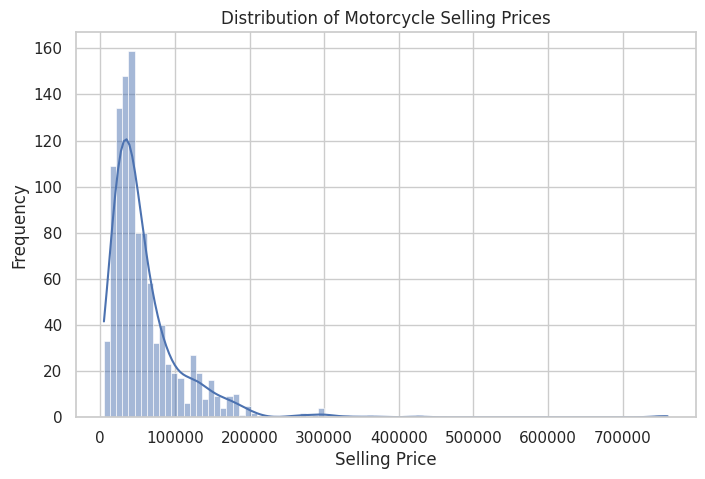

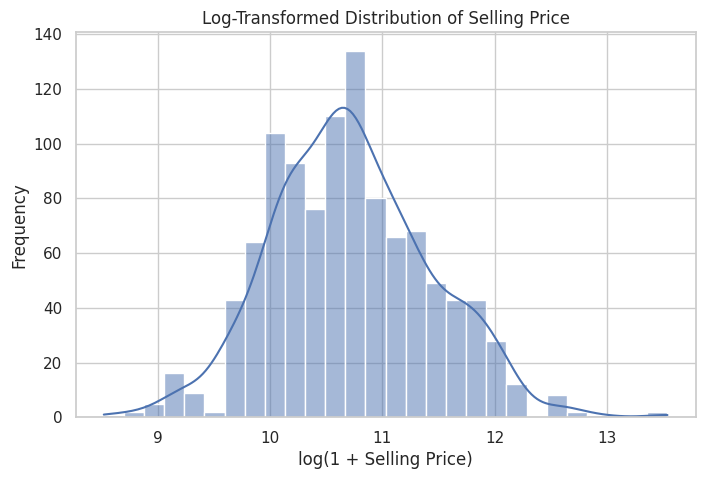

In [20]:
plt.figure(figsize=(8, 5))
sns.histplot(data["selling_price"], kde=True)
plt.title("Distribution of Motorcycle Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")

plt.savefig("selling_price_distribution.png", dpi=300, bbox_inches="tight")
files.download("selling_price_distribution.png")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(data["selling_price"]), kde=True)
plt.title("Log-Transformed Distribution of Selling Price")
plt.xlabel("log(1 + Selling Price)")
plt.ylabel("Frequency")
plt.show()

# The first graph shows that motorcycle selling prices are right-skewed. Most
# motorcycles sell for relatively low or moderate prices, while a smaller number of
# motorcycles have really high prices. These expensive motorcycles stretch the
# distribution to the right. The second graph uses `log(1 + selling_price)`, which
# makes the distribution more balanced. This tells us that using a log transformation
# of the target variable may help the model handle expensive outliers more effectively.



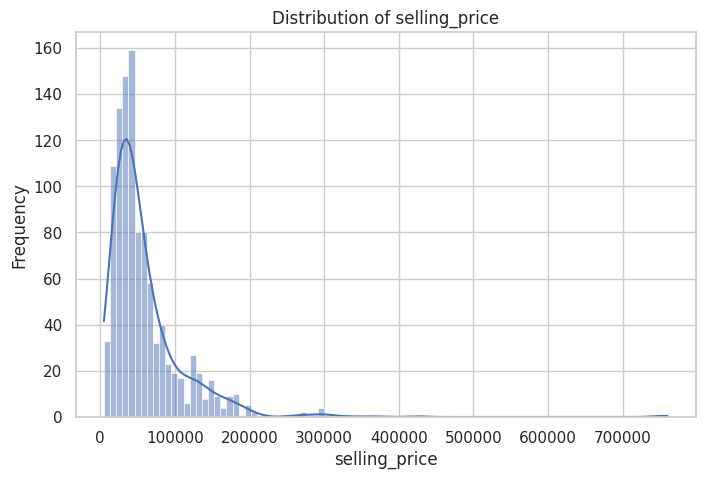

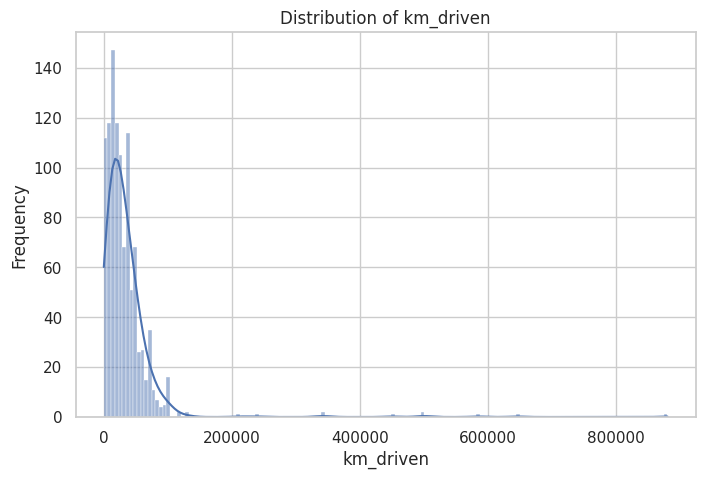

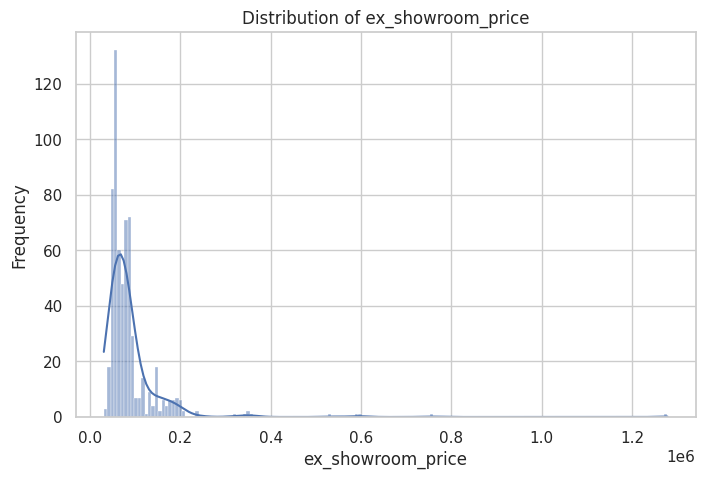

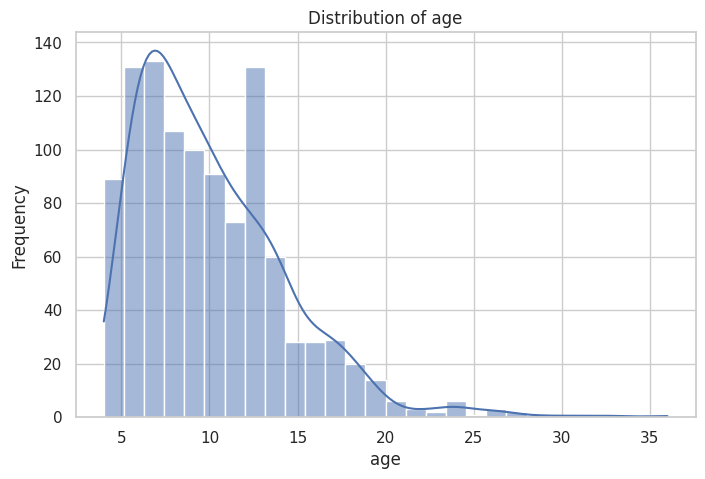

In [21]:
numeric_cols = ["selling_price", "km_driven", "ex_showroom_price", "age"]

for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(data[col].dropna(), kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
# These histograms show the distributions of the main numeric variables: `selling_price`,
# `km_driven`, `ex_showroom_price`, and `age`. Selling price and ex-showroom price are
# strongly right-skewed, meaning most motorcycles are in lower price ranges but a few
# are much more expensive. Kilometers driven is also skewed because most motorcycles
# have moderate mileage, while a few have extremely high mileage. Age is more spread
# out, but most motorcycles are from relatively recent years. These patterns show why
# cleaning outliers and possibly transforming price are important before modeling.



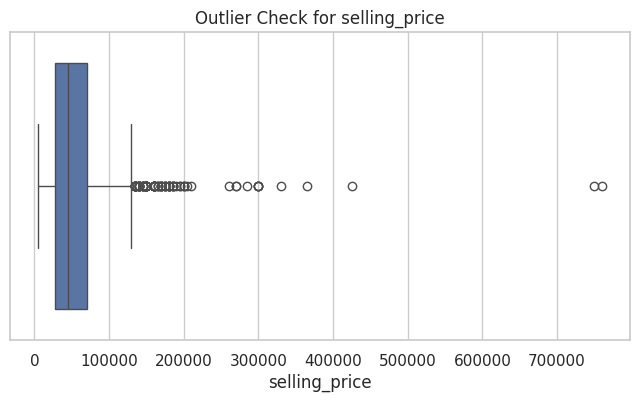

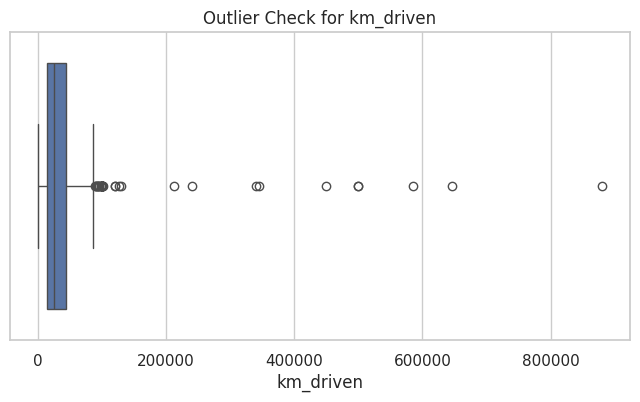

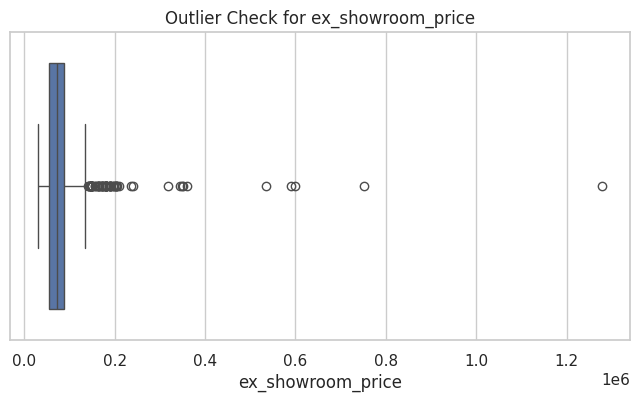

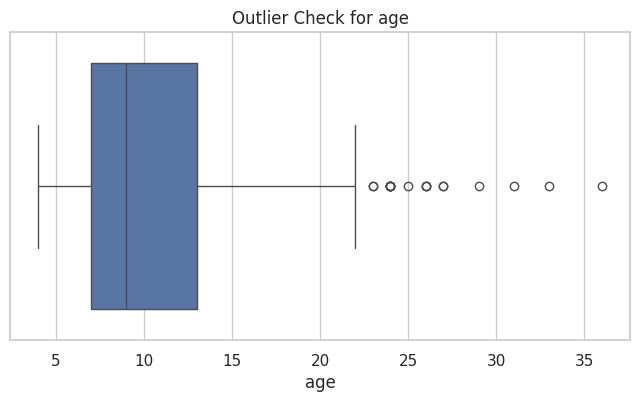

In [22]:
for col in ["selling_price", "km_driven", "ex_showroom_price", "age"]:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=data[col])
    plt.title(f"Outlier Check for {col}")
    plt.xlabel(col)
    plt.show()
# These boxplots help identify outliers in the numeric variables. Points far away from
# the main box represent unusually high or low values. The plots show clear outliers in
# `selling_price`, `km_driven`, and `ex_showroom_price`. For example, some motorcycles
# have extremely high mileage or very high prices compared with most listings. These
# outliers can strongly affect regression models, especially Linear Regression, so the
# dataset is later filtered to remove unrealistic or extreme values.


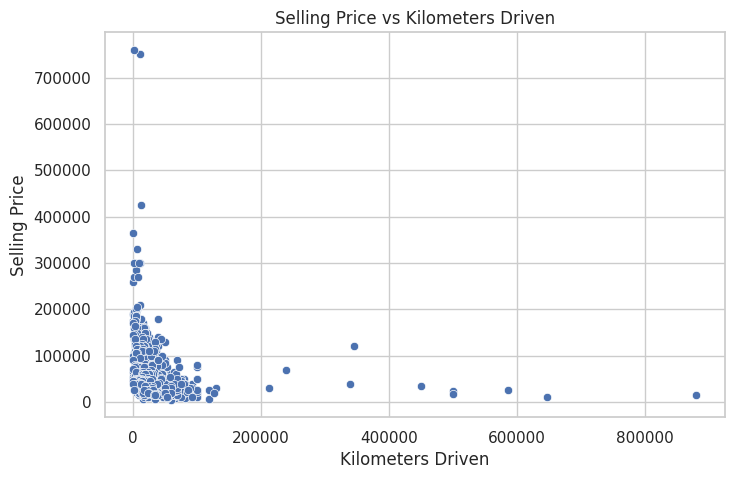

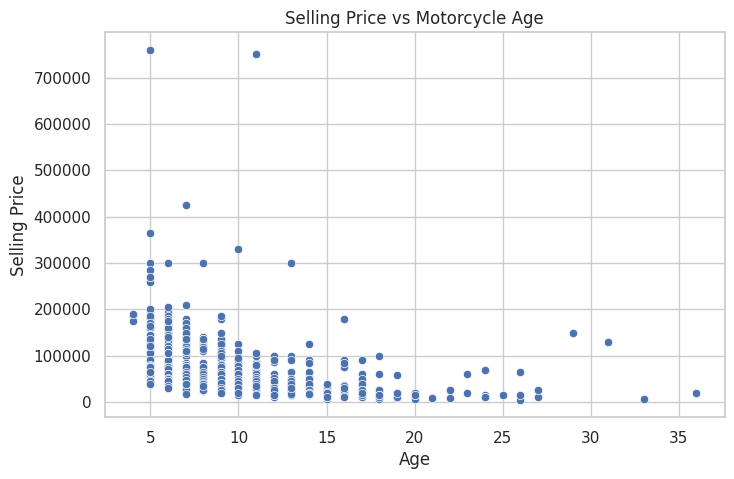

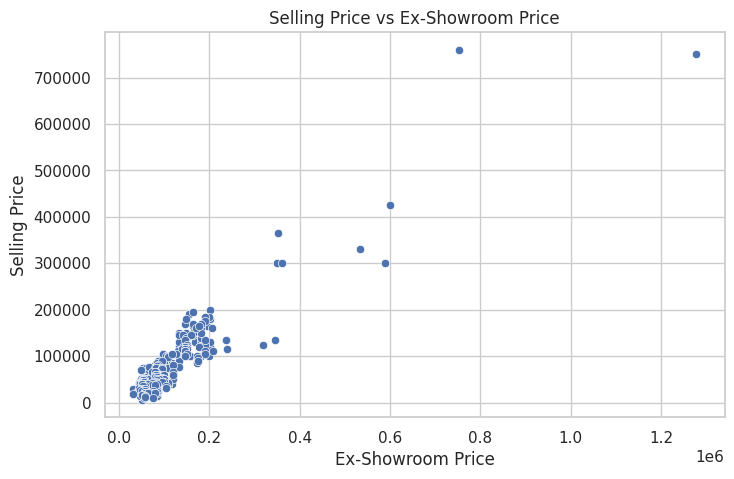

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="km_driven", y="selling_price")
plt.title("Selling Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="age", y="selling_price")
plt.title("Selling Price vs Motorcycle Age")
plt.xlabel("Age")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x="ex_showroom_price", y="selling_price")
plt.title("Selling Price vs Ex-Showroom Price")
plt.xlabel("Ex-Showroom Price")
plt.ylabel("Selling Price")
plt.show()
# These scatterplots show how selling price relates to mileage, age, and ex-showroom
# price. The `km_driven` plot suggests that motorcycles with very high mileage often
# have lower selling prices, although the relationship is not perfectly linear. The
# `age` plot shows that older motorcycles generally tend to sell for less, which matches
# the idea of depreciation. The `ex_showroom_price` plot shows a positive relationship:
# motorcycles that were more expensive when new often have higher resale prices.
# However, the points are spread out, which means price depends on multiple features,
# not just one variable.


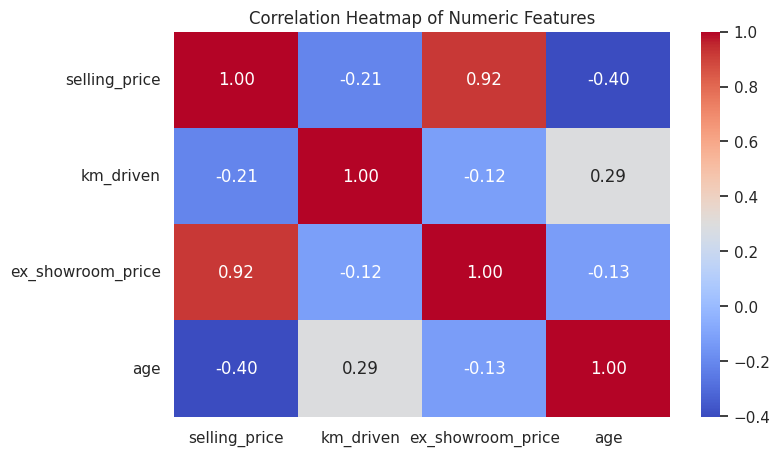

In [24]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    data[["selling_price", "km_driven", "ex_showroom_price", "age"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()
# The heatmap shows the linear correlation between numeric variables. `ex_showroom_price` is positively
# related to `selling_price`, which makes sense because motorcycles that cost more when
# new usually resell for more. `age` and `km_driven` tend to have weaker or negative
# relationships with selling price, meaning older or more heavily used motorcycles often
# sell for less. Since the correlations are not perfect, nonlinear models like Random
# Forest and Gradient Boosting may capture patterns that Linear Regression misses.



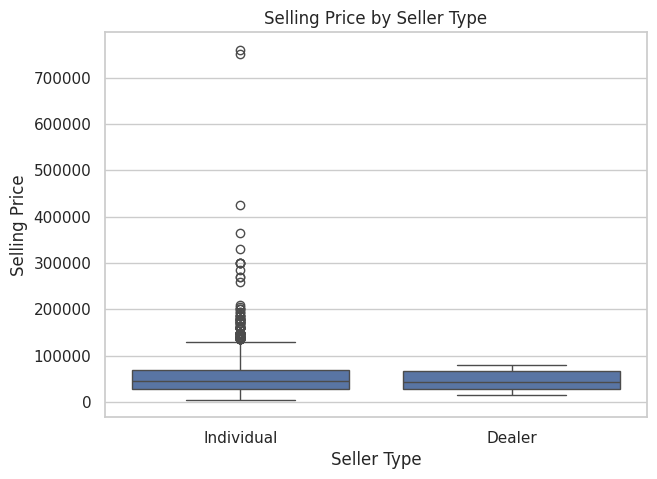

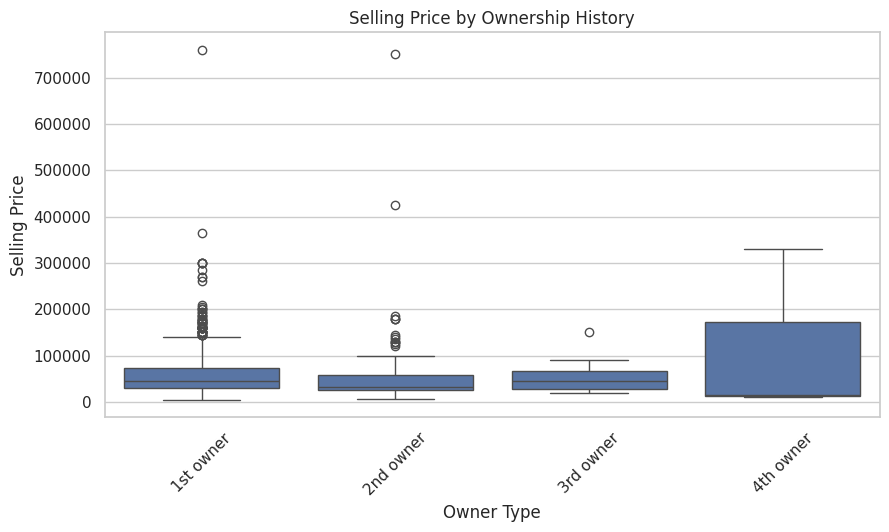

In [25]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=data, x="seller_type", y="selling_price")
plt.title("Selling Price by Seller Type")
plt.xlabel("Seller Type")
plt.ylabel("Selling Price")
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x="owner", y="selling_price")
plt.title("Selling Price by Ownership History")
plt.xlabel("Owner Type")
plt.ylabel("Selling Price")
plt.xticks(rotation=45)
plt.show()
# These boxplots compare selling price across categorical variables. The seller type
# plot compares individual sellers and dealers, but the dataset has very few dealer
# listings, so that comparison should be interpreted carefully. The ownership plot shows
# how price changes by ownership history. First-owner motorcycles generally appear to
# have higher resale prices than motorcycles with more previous owners. This matches
# real-world expectations because buyers usually value motorcycles more when they have
# had fewer owners.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

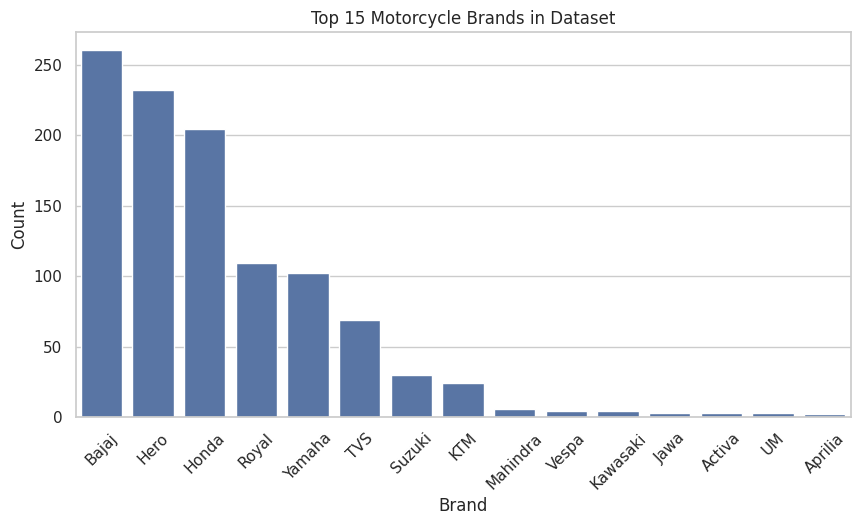

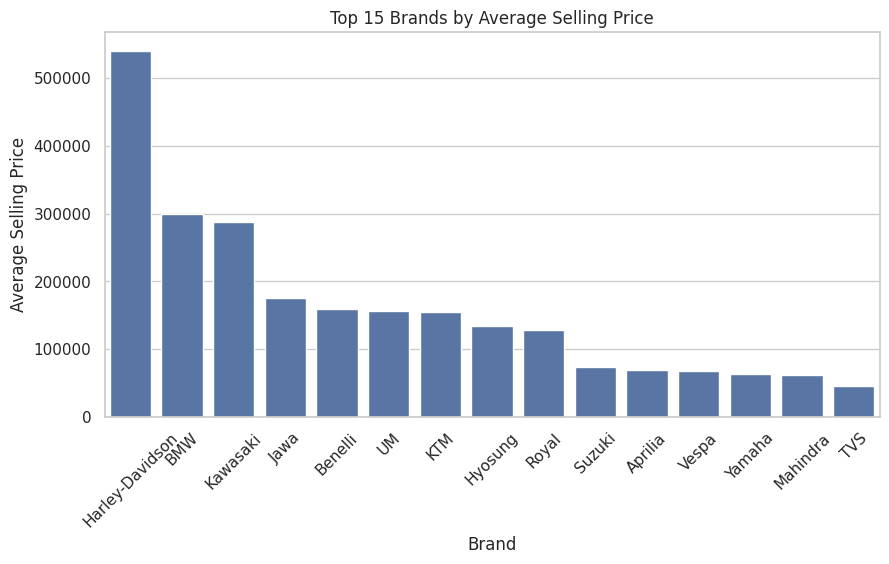

In [26]:
top_brands = data["brand"].value_counts().head(15)

plt.figure(figsize=(10, 5))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 15 Motorcycle Brands in Dataset")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.savefig("brand_counts.png", dpi=300, bbox_inches="tight")
files.download("brand_counts.png")
plt.show()

brand_avg_price = (
    data.groupby("brand")["selling_price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 5))
sns.barplot(x=brand_avg_price.index, y=brand_avg_price.values)
plt.title("Top 15 Brands by Average Selling Price")
plt.xlabel("Brand")
plt.ylabel("Average Selling Price")
plt.xticks(rotation=45)
plt.show()


In [27]:
# data cleaning
clean_data = data[
    (data["selling_price"] > 0) &
    (data["selling_price"] < 800000) &
    (data["km_driven"] >= 0) &
    (data["km_driven"] < 300000) &
    (data["age"] >= 0) &
    (data["age"] <= 30)
].copy()

print("Original dataset shape:", data.shape)
print("Cleaned dataset shape:", clean_data.shape)
print("Rows removed:", data.shape[0] - clean_data.shape[0])

display(clean_data.head())


Original dataset shape: (1061, 10)
Cleaned dataset shape: (1050, 10)
Rows removed: 11


,name,selling_price,year,seller_type,owner,km_driven,ex_showroom_price,age,brand,model_name
0,Royal Enfield Classic 350,175000,2019,Individual,1st owner,350,NaN,5,Royal,Royal Enfield Classic 350
1,Honda Dio,45000,2017,Individual,1st owner,5650,NaN,7,Honda,Honda Dio
2,Royal Enfield Classic Gunmetal Grey,150000,2018,Individual,1st owner,12000,148114.0,6,Royal,Royal Enfield Classic Gunmetal Grey
3,Yamaha Fazer FI V 2.0 [2016-2018],65000,2015,Individual,1st owner,23000,89643.0,9,Yamaha,Yamaha Fazer FI V 2.0 [2016-2018]
4,Yamaha SZ [2013-2014],20000,2011,Individual,2nd owner,21000,NaN,13,Yamaha,Yamaha SZ [2013-2014]


In [28]:
# we make sure to split the dataset into training and testing before clustering to prevent leakage
base_features = ["km_driven", "ex_showroom_price", "age", "seller_type", "owner", "brand"]

X_base = clean_data[base_features].copy()
y = clean_data["selling_price"].copy()

X_train_base, X_test_base, y_train, y_test = train_test_split(
    X_base,
    y,
    test_size=0.20,
    random_state=42
)

cluster_features = ["km_driven", "ex_showroom_price", "age", "seller_type", "owner", "brand"]

numeric_cluster_features = ["km_driven", "ex_showroom_price", "age"]
categorical_cluster_features = ["seller_type", "owner", "brand"]

cluster_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cluster_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

cluster_preprocessor = ColumnTransformer(
    transformers=[
        ("num", cluster_numeric_transformer, numeric_cluster_features),
        ("cat", cluster_categorical_transformer, categorical_cluster_features)
    ]
)

X_cluster_train_processed = cluster_preprocessor.fit_transform(X_train_base[cluster_features])
X_cluster_test_processed = cluster_preprocessor.transform(X_test_base[cluster_features])

print("Base training set:", X_train_base.shape)
print("Base testing set:", X_test_base.shape)


Base training set: (840, 6)
Base testing set: (210, 6)


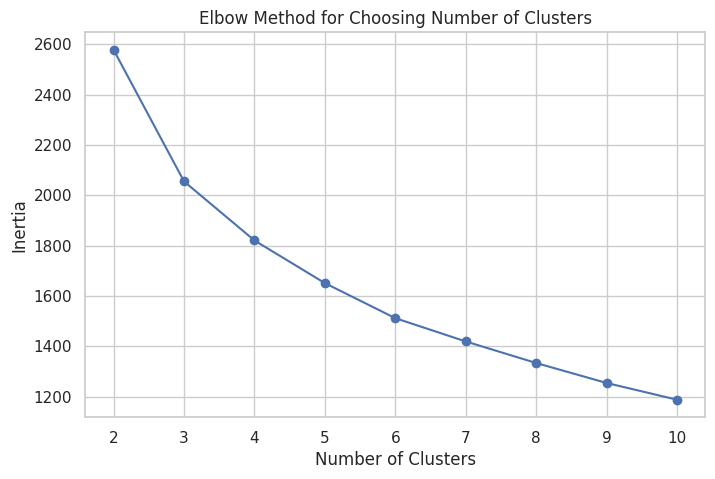

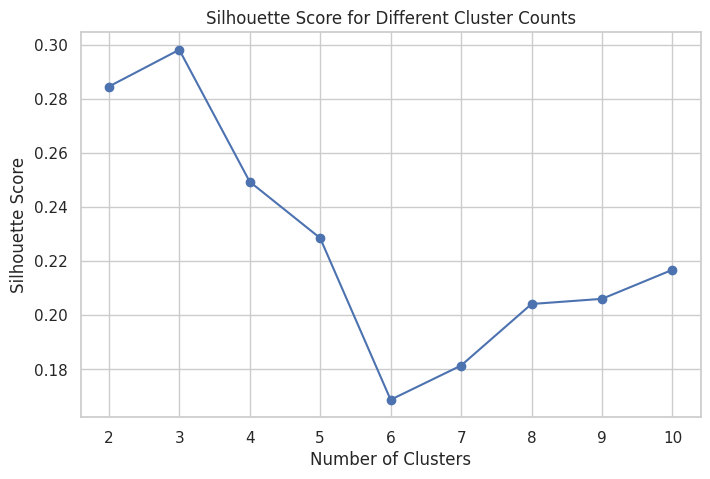

,k,Inertia,Silhouette Score
0,2,2577.794904,0.284473
1,3,2055.083631,0.298079
2,4,1820.568049,0.249334
3,5,1651.092857,0.228513
4,6,1511.924841,0.168802
5,7,1419.513484,0.181443
6,8,1333.842254,0.204171
7,9,1254.566266,0.206074
8,10,1188.097395,0.216807


In [29]:
inertias = []
silhouette_scores = []
k_values = range(2, 11)

for k in k_values:
    kmeans_candidate = KMeans(n_clusters=k, random_state=42, n_init=10)
    train_cluster_labels = kmeans_candidate.fit_predict(X_cluster_train_processed)

    inertias.append(kmeans_candidate.inertia_)
    silhouette_scores.append(silhouette_score(X_cluster_train_processed, train_cluster_labels))

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertias, marker="o")
plt.title("Elbow Method for Choosing Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker="o")
plt.title("Silhouette Score for Different Cluster Counts")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "Inertia": inertias,
    "Silhouette Score": silhouette_scores
})

display(silhouette_df)
# Based on the elbow and silhouette plots, we selected 3 clusters. The silhouette score is highest when k = 3,
# meaning the clusters are most clearly separated at this value. The elbow plot also shows that inertia decreases
# substantially up to around 3 clusters, after which the improvement becomes more gradual. Therefore, 3 clusters
# provides a good balance between model simplicity and meaningful grouping.


In [30]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

train_clusters = kmeans.fit_predict(X_cluster_train_processed)
test_clusters = kmeans.predict(X_cluster_test_processed)

X_train = X_train_base.copy()
X_test = X_test_base.copy()

X_train["cluster"] = train_clusters.astype(str)
X_test["cluster"] = test_clusters.astype(str)

clean_data = clean_data.copy()
clean_data["cluster"] = np.nan
clean_data.loc[X_train.index, "cluster"] = X_train["cluster"]
clean_data.loc[X_test.index, "cluster"] = X_test["cluster"]

X = pd.concat([X_train, X_test]).sort_index()
y = clean_data["selling_price"]

print("Training cluster counts:")
print(X_train["cluster"].value_counts().sort_index())

print("\nTesting cluster counts:")
print(X_test["cluster"].value_counts().sort_index())

print("\nOverall cluster counts:")
print(clean_data["cluster"].value_counts().sort_index())


Training cluster counts:
cluster
0    556
1    279
2      5
Name: count, dtype: int64

Testing cluster counts:
cluster
0    143
1     67
Name: count, dtype: int64

Overall cluster counts:
cluster
0    699
1    346
2      5
Name: count, dtype: int64


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

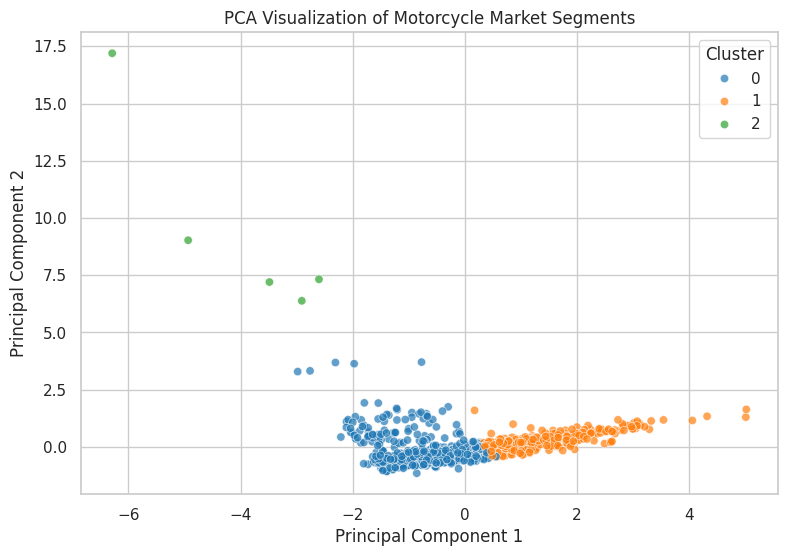

In [31]:
pca = PCA(n_components=2, random_state=42)

X_cluster_all_processed = cluster_preprocessor.transform(X_base[cluster_features])

if hasattr(X_cluster_train_processed, "toarray"):
    X_cluster_train_for_pca = X_cluster_train_processed.toarray()
    X_cluster_all_for_pca = X_cluster_all_processed.toarray()
else:
    X_cluster_train_for_pca = X_cluster_train_processed
    X_cluster_all_for_pca = X_cluster_all_processed

pca.fit(X_cluster_train_for_pca)
X_pca = pca.transform(X_cluster_all_for_pca)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": clean_data["cluster"].astype(str),
    "selling_price": clean_data["selling_price"]
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="tab10",
    alpha=0.7
)
plt.title("PCA Visualization of Motorcycle Market Segments")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.savefig("pca_clusters.png", dpi=300, bbox_inches="tight")
files.download("pca_clusters.png")
plt.show()
# This PCA plot visualizes the K-Means clusters in two dimensions. PCA compresses the processed motorcycle features into two principal components
# so that the clusters can be shown on a scatterplot. Cluster 0 and Cluster 1 contain most of the motorcycles and overlap somewhat, meaning many
# normal listings are fairly similar. Cluster 2 has only a few points and is separated from the main group, suggesting it represents unusual or
# premium motorcycles with feature values different from the majority of the dataset. This plot helps confirm that the clustering step is finding
# different market segments, although the separation is not perfect.


selling_price                              km_driven           \
                count           mean    median          mean   median   
cluster                                                                 
0                 699   71158.499285   55000.0  19708.145923  17500.0   
1                 346   30434.390173   25000.0  52948.641618  50000.0   
2                   5  513000.000000  425000.0   9380.000000  12000.0   

        ex_showroom_price                  age         
                     mean    median       mean median  
cluster                                                
0            88122.370130   75502.0   7.865522    8.0  
1            66990.103226   64589.0  14.430636   14.0  
2           750404.000000  599000.0   9.200000   10.0

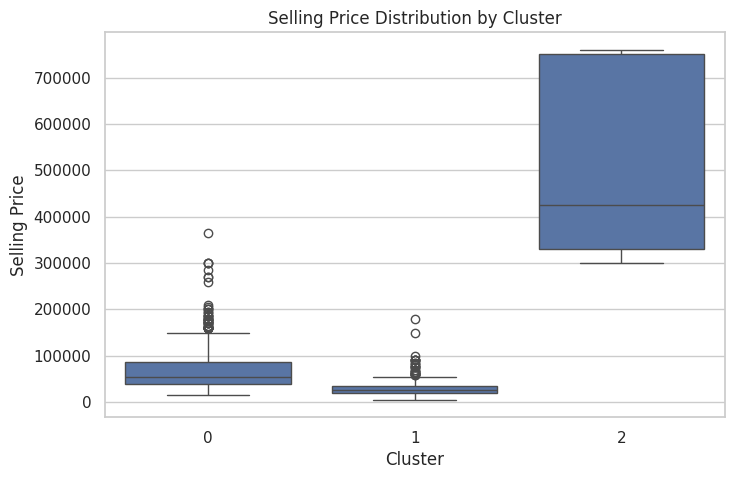

In [32]:
cluster_summary = clean_data.groupby("cluster").agg({
    "selling_price": ["count", "mean", "median"],
    "km_driven": ["mean", "median"],
    "ex_showroom_price": ["mean", "median"],
    "age": ["mean", "median"]
})

display(cluster_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=clean_data, x="cluster", y="selling_price")
plt.title("Selling Price Distribution by Cluster")
plt.xlabel("Cluster")
plt.ylabel("Selling Price")
plt.show()
# The cluster summary table shows the average and median characteristics of each market segment. Cluster 0 is the largest group, with 699
# motorcycles, a median selling price of 55,000, moderate mileage, and a median age of 8 years. Cluster 1 has 346 motorcycles and appears to
# represent older, higher-mileage, lower-price motorcycles, with a median selling price of 25,000 and median age of 14 years. Cluster 2 contains
# only 5 motorcycles, but they are much more expensive, with a median selling price of 425,000 and much higher showroom prices. This suggests
# that Cluster 2 captures rare premium motorcycles, while Clusters 0 and 1 represent more common used motorcycle segments.


In [33]:
print("Features used for modeling:")
print(X_train.columns)

print("\nTarget variable:")
print(y.name)

print("\nTraining set:", X_train.shape)
print("Testing set:", X_test.shape)


Features used for modeling:
Index(['km_driven', 'ex_showroom_price', 'age', 'seller_type', 'owner',
       'brand', 'cluster'],
      dtype='object')

Target variable:
selling_price

Training set: (840, 7)
Testing set: (210, 7)


In [34]:
numeric_features = ["km_driven", "ex_showroom_price", "age"]
categorical_features = ["seller_type", "owner", "brand", "cluster"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


In [35]:
baseline_pred = np.full(shape=len(y_test), fill_value=y_train.mean())

baseline_results = pd.DataFrame({
    "Model": ["Baseline Mean Prediction"],
    "MAE": [mean_absolute_error(y_test, baseline_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, baseline_pred))],
    "R2 Score": [r2_score(y_test, baseline_pred)]
})

display(baseline_results)


,Model,MAE,RMSE,R2 Score
0,Baseline Mean Prediction,32996.02585,45488.417122,-0.002883


In [36]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

results = []
trained_models = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": model_name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "R2 Score": r2_score(y_test, y_pred)
    })

    trained_models[model_name] = pipeline

results_df = pd.DataFrame(results)

model_comparison = pd.concat([baseline_results, results_df], ignore_index=True)
model_comparison = model_comparison.sort_values(by="R2 Score", ascending=False)

display(model_comparison)


,Model,MAE,RMSE,R2 Score
2,Random Forest,11082.180072,17081.877559,0.858577
3,Gradient Boosting,12039.418293,18313.352834,0.837451
1,Linear Regression,14615.086384,23551.922017,0.731156
0,Baseline Mean Prediction,32996.025850,45488.417122,-0.002883


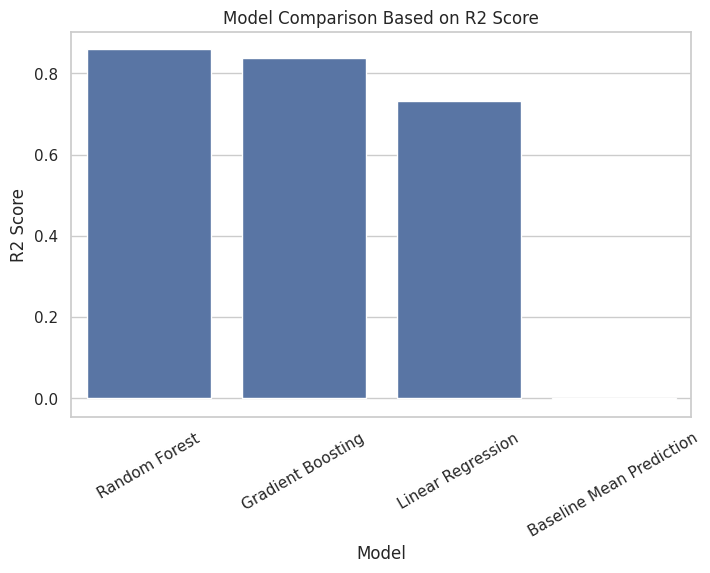

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

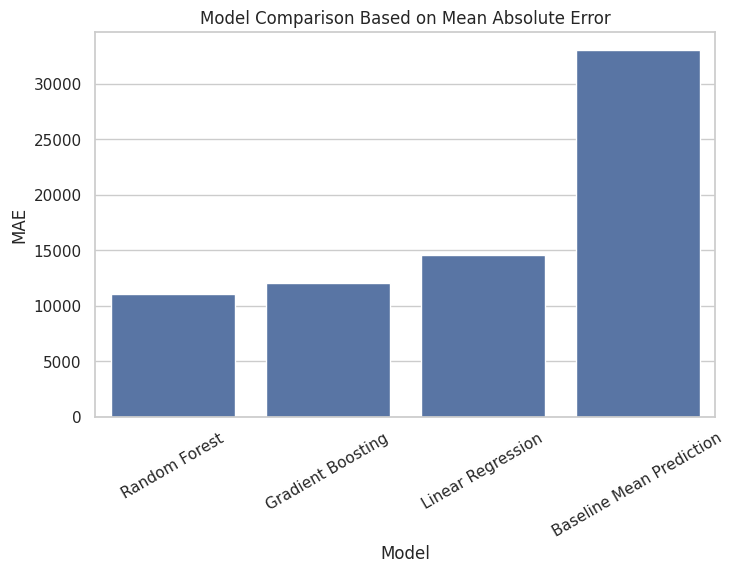

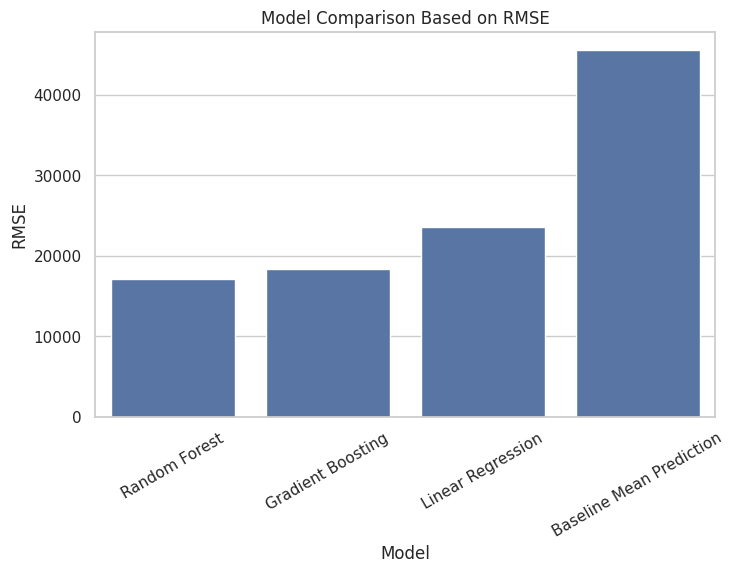

In [37]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x="Model", y="R2 Score")
plt.title("Model Comparison Based on R2 Score")
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.xticks(rotation=30)

plt.savefig("model_comparison.png", dpi =300, bbox_inches="tight")
plt.show()
files.download("model_comparison.png")

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x="Model", y="MAE")
plt.title("Model Comparison Based on Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(8, 5))
sns.barplot(data=model_comparison, x="Model", y="RMSE")
plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()


In [38]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

gb_log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gb_log_pipeline.fit(X_train, y_train_log)

y_pred_log = gb_log_pipeline.predict(X_test)

y_pred_gb_log = np.expm1(y_pred_log)
y_test_original = np.expm1(y_test_log)

gb_log_results = pd.DataFrame({
    "Model": ["Gradient Boosting + Log Target"],
    "MAE": [mean_absolute_error(y_test_original, y_pred_gb_log)],
    "RMSE": [np.sqrt(mean_squared_error(y_test_original, y_pred_gb_log))],
    "R2 Score": [r2_score(y_test_original, y_pred_gb_log)]
})

display(gb_log_results)


,Model,MAE,RMSE,R2 Score
0,Gradient Boosting + Log Target,11654.667811,17972.198859,0.843451


In [39]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

gb_search = RandomizedSearchCV(
    gb_pipeline,
    param_distributions=gb_param_grid,
    n_iter=25,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

gb_search.fit(X_train, y_train)

print("Best Gradient Boosting Parameters:")
print(gb_search.best_params_)

print("\nBest Cross-Validation R2:")
print(gb_search.best_score_)


Best Gradient Boosting Parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_depth': 4, 'model__learning_rate': 0.05}

Best Cross-Validation R2:
0.8237990172618691


In [40]:
best_gb = gb_search.best_estimator_

y_pred_tuned_gb = best_gb.predict(X_test)

tuned_gb_results = pd.DataFrame({
    "Model": ["Tuned Gradient Boosting"],
    "MAE": [mean_absolute_error(y_test, y_pred_tuned_gb)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred_tuned_gb))],
    "R2 Score": [r2_score(y_test, y_pred_tuned_gb)]
})

display(tuned_gb_results)


,Model,MAE,RMSE,R2 Score
0,Tuned Gradient Boosting,12121.447522,18116.964682,0.840919


In [41]:
final_results = pd.concat([
    model_comparison,
    gb_log_results,
    tuned_gb_results
], ignore_index=True)

final_results = final_results.sort_values(by="R2 Score", ascending=False)

display(final_results)


,Model,MAE,RMSE,R2 Score
0,Random Forest,11082.180072,17081.877559,0.858577
4,Gradient Boosting + Log Target,11654.667811,17972.198859,0.843451
5,Tuned Gradient Boosting,12121.447522,18116.964682,0.840919
1,Gradient Boosting,12039.418293,18313.352834,0.837451
2,Linear Regression,14615.086384,23551.922017,0.731156
3,Baseline Mean Prediction,32996.025850,45488.417122,-0.002883


In [42]:
best_model_name = final_results.iloc[0]["Model"]

print("Best model based on R2 Score:", best_model_name)

if best_model_name == "Tuned Gradient Boosting":
    best_model = best_gb
elif best_model_name == "Gradient Boosting + Log Target":
    best_model = gb_log_pipeline
elif best_model_name in trained_models:
    best_model = trained_models[best_model_name]
else:
    best_model = best_gb

print("Selected best model:", best_model_name)


Best model based on R2 Score: Random Forest
Selected best model: Random Forest


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

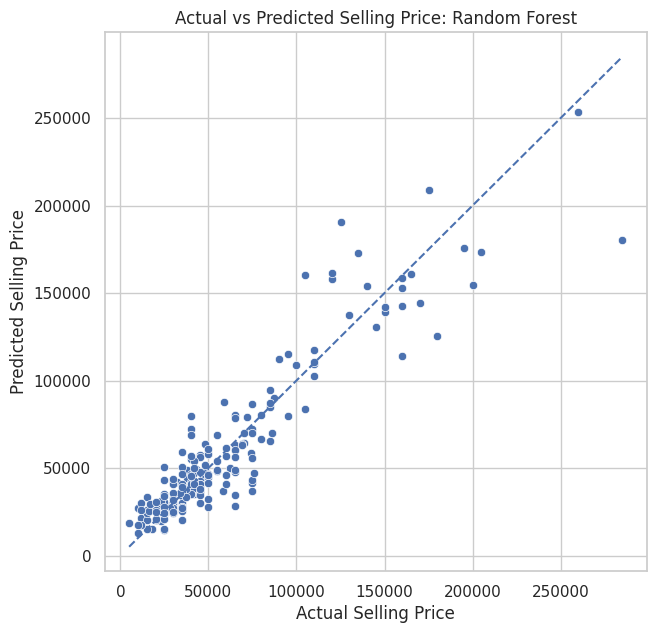

In [43]:
if best_model_name == "Gradient Boosting + Log Target":
    y_pred_best = np.expm1(best_model.predict(X_test))
else:
    y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
sns.scatterplot(x=y_test, y=y_pred_best)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)
plt.title(f"Actual vs Predicted Selling Price: {best_model_name}")
plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")

plt.savefig("actual_vs_predicted.png", dpi=300, bbox_inches="tight")
files.download("actual_vs_predicted.png")
plt.show()


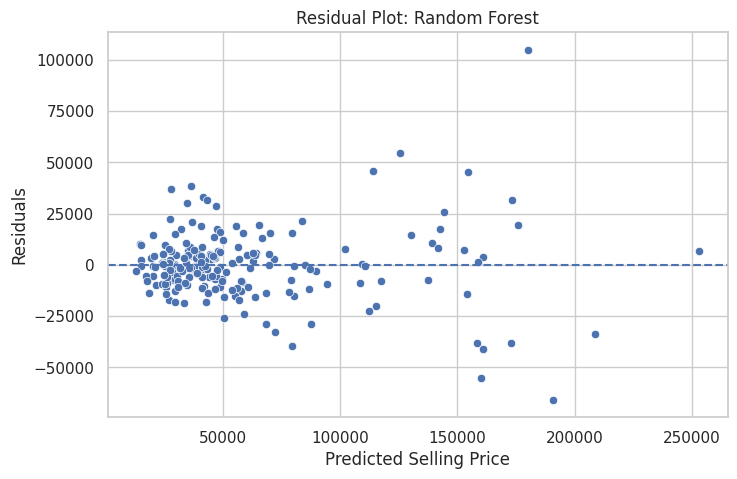

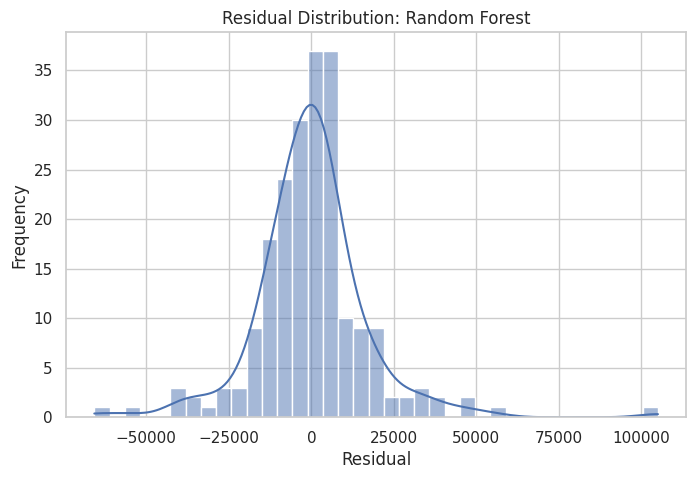

In [44]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_best, y=residuals)
plt.axhline(0, linestyle="--")
plt.title(f"Residual Plot: {best_model_name}")
plt.xlabel("Predicted Selling Price")
plt.ylabel("Residuals")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.title(f"Residual Distribution: {best_model_name}")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()


Actual      Predicted Absolute Error              
                            mean           mean           mean        median
Price Range                                                                 
Low Price           22157.627119   27054.848413    6537.090877   5331.968254
Medium-Low Price    37723.404255   41996.270071    7873.098298   4875.020000
Medium-High Price   53788.442308   49842.008828    9833.606368   7322.388889
High Price         120769.403846  115273.996838   20388.198120  15050.833333

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

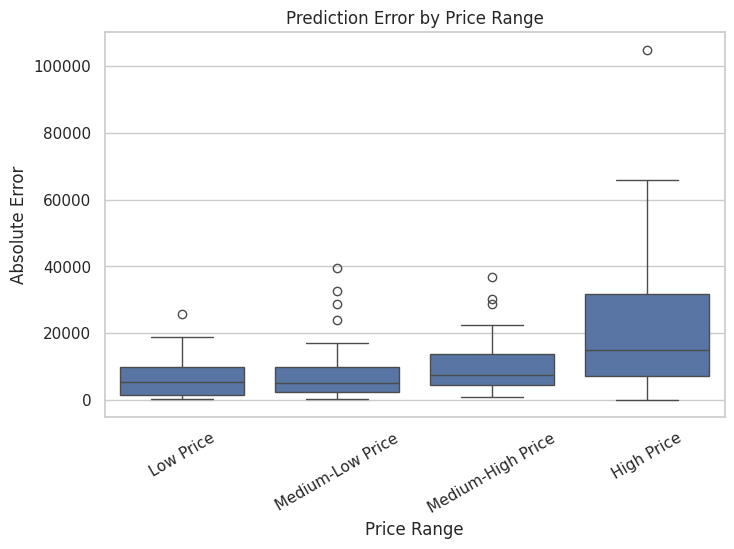

In [45]:
error_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred_best,
    "Absolute Error": np.abs(y_test - y_pred_best)
})

error_df["Price Range"] = pd.qcut(
    error_df["Actual"],
    q=4,
    labels=["Low Price", "Medium-Low Price", "Medium-High Price", "High Price"]
)

price_range_errors = error_df.groupby("Price Range").agg({
    "Actual": "mean",
    "Predicted": "mean",
    "Absolute Error": ["mean", "median"]
})

display(price_range_errors)

plt.figure(figsize=(8, 5))
sns.boxplot(data=error_df, x="Price Range", y="Absolute Error")
plt.title("Prediction Error by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Absolute Error")
plt.xticks(rotation=30)

plt.savefig("error_by_price_range.png", dpi=300, bbox_inches="tight")
files.download("error_by_price_range.png")
plt.show()


,Feature,Importance
1,ex_showroom_price,0.558114
2,age,0.146770
22,brand_Royal,0.138558
0,km_driven,0.057177
19,brand_KTM,0.048888
31,cluster_2,0.012818
23,brand_Suzuki,0.011175
6,owner_2nd owner,0.003634
14,brand_Harley-Davidson,0.003432
12,brand_Bajaj,0.003165


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

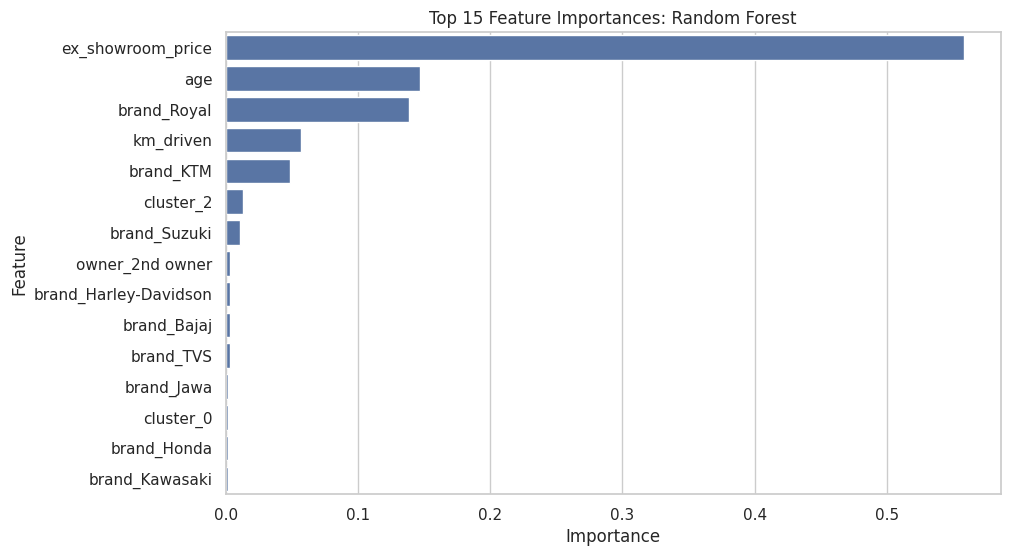

In [46]:
model_step = best_model.named_steps["model"]
preprocessor_fitted = best_model.named_steps["preprocessor"]

cat_features = (
    preprocessor_fitted
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

feature_names = np.concatenate([numeric_features, cat_features])

if hasattr(model_step, "feature_importances_"):
    feature_importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_step.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    display(feature_importance_df.head(15))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x="Importance", y="Feature")
    plt.title(f"Top 15 Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.savefig("feature_importance.png", dpi=300, bbox_inches="tight")
    files.download("feature_importance.png")
    plt.show()
else:
    print("This model does not provide feature importances.")


In [47]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_base), start=1):
    X_fold_train_base = X_base.iloc[train_idx].copy()
    X_fold_val_base = X_base.iloc[val_idx].copy()
    y_fold_train = y.iloc[train_idx]
    y_fold_val = y.iloc[val_idx]

    fold_cluster_preprocessor = clone(cluster_preprocessor)

    X_fold_cluster_train = fold_cluster_preprocessor.fit_transform(
        X_fold_train_base[cluster_features]
    )

    X_fold_cluster_val = fold_cluster_preprocessor.transform(
        X_fold_val_base[cluster_features]
    )

    fold_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

    X_fold_train = X_fold_train_base.copy()
    X_fold_val = X_fold_val_base.copy()

    X_fold_train["cluster"] = fold_kmeans.fit_predict(X_fold_cluster_train).astype(str)
    X_fold_val["cluster"] = fold_kmeans.predict(X_fold_cluster_val).astype(str)

    fold_model = clone(best_model)

    if best_model_name == "Gradient Boosting + Log Target":
        fold_model.fit(X_fold_train, np.log1p(y_fold_train))
        fold_pred = np.expm1(fold_model.predict(X_fold_val))
    else:
        fold_model.fit(X_fold_train, y_fold_train)
        fold_pred = fold_model.predict(X_fold_val)

    fold_r2 = r2_score(y_fold_val, fold_pred)
    cv_scores.append(fold_r2)

    print(f"Fold {fold} R2: {fold_r2:.4f}")

cv_scores = np.array(cv_scores)

print("\nCross-validation R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Standard deviation:", cv_scores.std())


Fold 1 R2: 0.8694
Fold 2 R2: 0.6886
Fold 3 R2: 0.8313
Fold 4 R2: 0.6896
Fold 5 R2: 0.8474

Cross-validation R2 scores: [0.86935338 0.68864845 0.83134543 0.68963402 0.84737352]
Mean CV R2: 0.7852709592479423
Standard deviation: 0.07941255711586806


In [48]:
final_results.to_csv("final_model_results.csv", index=False)
error_df.to_csv("prediction_error_analysis.csv", index=False)

if "feature_importance_df" in globals():
    feature_importance_df.to_csv("feature_importance.csv", index=False)

cluster_summary.to_csv("cluster_summary.csv")

print("Files saved successfully.")


Files saved successfully.


In [49]:
from google.colab import files

files.download("final_model_results.csv")
files.download("prediction_error_analysis.csv")
files.download("cluster_summary.csv")

if "feature_importance_df" in globals():
    files.download("feature_importance.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>